# SBV2 09 - Composite Render Proof (Family B)

This notebook closes the Sandbox V2 evidence arc with a concrete generation artefact: it takes the two `ready_for_generation` documents from Notebook 8 (`synthetic_menu_concept_0000` and `nypl_expanded_144`), renders each one through a deterministic schema → HTML/CSS → PDF → PNG pipeline, and re-OCRs the rendered PNG to verify that exact item names and prices survive the round trip.

The point is not to claim that this beats text-to-image generation; it is to demonstrate the **production-safe Family B path** named in the v2 plan — *deterministic SVG/HTML fusion remains the reliable fallback for exact commercial menus*. The render-and-OCR-verify loop turns generation into a measurable contract.

## Contract

Inputs:

- `data/processed/sandbox_v2/menu_generation_schema.csv`
- `outputs/sandbox_v2/audit_tables/sbv2_08_prompt_pack_candidates.csv`
- `data/interim/sandbox_v2/manifests/sbv2_03_document_manifest.csv`

Outputs:

- `outputs/sandbox_v2/composite_renders/<slug>.html` and `.pdf` and `.png` per (document × style)
- `outputs/sandbox_v2/audit_tables/sbv2_09_composite_render_audit.csv` (and `.parquet`)
- `outputs/sandbox_v2/audit_tables/sbv2_09_composite_render_summary.json`
- `outputs/figures/sandbox_v2/composite_side_by_side/<slug>__side_by_side.jpg` per render
- `outputs/figures/sandbox_v2/sbv2_09_composite_render_proof.jpg` (headline figure)

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "sandbox_v2").exists():
    candidates = [parent for parent in ROOT.parents if (parent / "sandbox_v2").exists()]
    if candidates:
        ROOT = candidates[0]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

CACHE_DIR = Path(os.environ.get("MENUFORGE_CACHE_HOME", ROOT / ".cache")).resolve()
for env_name, relative_path in {
    "XDG_CACHE_HOME": "",
    "PADDLE_PDX_CACHE_HOME": "paddlex",
    "MPLCONFIGDIR": "matplotlib",
    "JUPYTER_CONFIG_DIR": "jupyter_config",
    "JUPYTER_DATA_DIR": "jupyter_data",
    "JUPYTER_RUNTIME_DIR": "jupyter_runtime",
    "IPYTHONDIR": "ipython",
}.items():
    target = (CACHE_DIR / relative_path) if relative_path else CACHE_DIR
    target.mkdir(parents=True, exist_ok=True)
    os.environ.setdefault(env_name, str(target))
os.environ.setdefault("PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK", "True")

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)
print({"ROOT": str(ROOT), "CACHE_DIR": str(CACHE_DIR)})

{'ROOT': '/home/endy/menuforge', 'CACHE_DIR': '/home/endy/menuforge/.cache'}


In [2]:
# Defaults render the two NB08 ready_for_generation documents in two style templates.
# Override via env vars if you want to add or replace.
RUN_RENDER = os.environ.get("SBV2_RUN_RENDER", "1") == "1"
RUN_OCR_CHECK = os.environ.get("SBV2_RUN_OCR_CHECK", "1") == "1"

DOCS_TEXT = os.environ.get("SBV2_RENDER_DOCS", "").strip()
DOCUMENT_IDS = [d.strip() for d in DOCS_TEXT.split(",") if d.strip()] or None

STYLES_TEXT = os.environ.get("SBV2_RENDER_STYLES", "modern_minimalist,vintage_serif").strip()
STYLES = [s.strip() for s in STYLES_TEXT.split(",") if s.strip()]

print({"RUN_RENDER": RUN_RENDER, "RUN_OCR_CHECK": RUN_OCR_CHECK, "DOCUMENT_IDS": DOCUMENT_IDS, "STYLES": STYLES})

{'RUN_RENDER': True, 'RUN_OCR_CHECK': True, 'DOCUMENT_IDS': None, 'STYLES': ['modern_minimalist', 'vintage_serif']}


### Preflight — confirm the Family B inputs and tooling are present

If WeasyPrint or pypdfium2 are missing the run will fail loudly. Schema and prompt-pack candidates must come from earlier sandbox notebooks.

In [3]:
preflight_paths = {
    "menu_generation_schema": ROOT / "data/processed/sandbox_v2/menu_generation_schema.csv",
    "prompt_pack_candidates": ROOT / "outputs/sandbox_v2/audit_tables/sbv2_08_prompt_pack_candidates.csv",
    "document_manifest": ROOT / "data/interim/sandbox_v2/manifests/sbv2_03_document_manifest.csv",
}
preflight_files = pd.DataFrame(
    [
        {
            "input": name,
            "path": str(path.relative_to(ROOT)),
            "exists": path.exists(),
            "bytes": path.stat().st_size if path.exists() else 0,
        }
        for name, path in preflight_paths.items()
    ]
)
display(preflight_files)
missing = preflight_files.loc[~preflight_files["exists"], "path"].tolist()
if missing:
    raise FileNotFoundError(f"Run earlier sandbox notebooks first; missing: {missing}")

tool_status = []
for mod in ("weasyprint", "pypdfium2"):
    try:
        imported = __import__(mod)
        tool_status.append({"tool": mod, "available": True, "version": getattr(imported, "__version__", "?")})
    except Exception as exc:
        tool_status.append({"tool": mod, "available": False, "version": f"{type(exc).__name__}: {exc}"})
display(pd.DataFrame(tool_status))
if any(not row["available"] for row in tool_status):
    raise RuntimeError("Missing rendering tooling; install weasyprint and pypdfium2 before running.")

,input,path,exists,bytes
0,menu_generation_schema,data/processed/sandbox_v2/menu_generation_schema.csv,True,136419
1,prompt_pack_candidates,outputs/sandbox_v2/audit_tables/sbv2_08_prompt_pack_candidates.csv,True,1672
2,document_manifest,data/interim/sandbox_v2/manifests/sbv2_03_document_manifest.csv,True,1293172


,tool,available,version
0,weasyprint,True,68.1
1,pypdfium2,True,?


In [4]:
from sandbox_v2.menu_render import write_outputs

summary_path = ROOT / "outputs/sandbox_v2/audit_tables/sbv2_09_composite_render_summary.json"
if RUN_RENDER:
    summary = write_outputs(
        document_ids=DOCUMENT_IDS,
        styles=STYLES,
        run_ocr_check=RUN_OCR_CHECK,
    )
elif summary_path.exists():
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
else:
    raise FileNotFoundError("RUN_RENDER is false and no previous SBV2 09 summary exists.")

print(json.dumps({
    "document_ids": summary.get("document_ids"),
    "styles": summary.get("styles"),
    "render_rows": summary.get("render_rows"),
    "render_ok_rows": summary.get("render_ok_rows"),
    "render_failed_rows": summary.get("render_failed_rows"),
    "ocr_engine_status": summary.get("ocr_engine_status"),
    "ocr_check_ok_rows": summary.get("ocr_check_ok_rows"),
    "mean_item_name_coverage": summary.get("mean_item_name_coverage"),
    "mean_price_coverage": summary.get("mean_price_coverage"),
}, indent=2))

/home/endy/menuforge/.venv/lib/python3.11/site-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/endy/menuforge/.cache/paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/endy/menuforge/.cache/paddlex/official_models/en_PP-OCRv5_mobile_rec`.
Resized image size (1241x10564) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (1241x8802) exceeds max_side_limit of 4000. Resizing to fit within limit.


{
  "document_ids": [
    "nypl_expanded_144",
    "synthetic_menu_concept_0000"
  ],
  "styles": [
    "modern_minimalist",
    "vintage_serif"
  ],
  "render_rows": 4,
  "render_ok_rows": 4,
  "render_failed_rows": 0,
  "ocr_engine_status": "ready",
  "ocr_check_ok_rows": 4,
  "mean_item_name_coverage": 1.0,
  "mean_price_coverage": 1.0
}


In [5]:
audit = pd.read_csv(ROOT / summary["audit_csv"])
preview_cols = [
    "document_id",
    "style",
    "render_status",
    "schema_row_count",
    "render_runtime_seconds",
    "ocr_after_render_status",
    "ocr_after_render_runtime_seconds",
    "ocr_after_render_region_count",
    "items_total",
    "items_recovered",
    "item_name_coverage",
    "prices_total",
    "prices_recovered",
    "price_coverage",
]
display(Markdown("### Composite Render Audit"))
display(audit[[c for c in preview_cols if c in audit.columns]])
if audit["error"].astype(str).str.strip().any():
    display(Markdown("### Errors"))
    display(audit.loc[audit["error"].astype(str).str.strip() != "", ["document_id", "style", "render_status", "error"]])

### Composite Render Audit

,document_id,style,render_status,schema_row_count,render_runtime_seconds,ocr_after_render_status,ocr_after_render_runtime_seconds,ocr_after_render_region_count,items_total,items_recovered,item_name_coverage,prices_total,prices_recovered,price_coverage
0,nypl_expanded_144,modern_minimalist,ok,123,0.811,ok,13.434,255,123,123,1.0,123,123,1.0
1,nypl_expanded_144,vintage_serif,ok,123,2.922,ok,15.141,255,123,123,1.0,123,123,1.0
2,synthetic_menu_concept_0000,modern_minimalist,ok,10,0.155,ok,3.768,36,10,10,1.0,10,10,1.0
3,synthetic_menu_concept_0000,vintage_serif,ok,10,0.367,ok,5.027,37,10,10,1.0,10,10,1.0


### Errors

,document_id,style,render_status,error
0,nypl_expanded_144,modern_minimalist,ok,NaN
1,nypl_expanded_144,vintage_serif,ok,NaN
2,synthetic_menu_concept_0000,modern_minimalist,ok,NaN
3,synthetic_menu_concept_0000,vintage_serif,ok,NaN


### Headline figure — Schema → HTML/CSS render, side-by-side with the source image

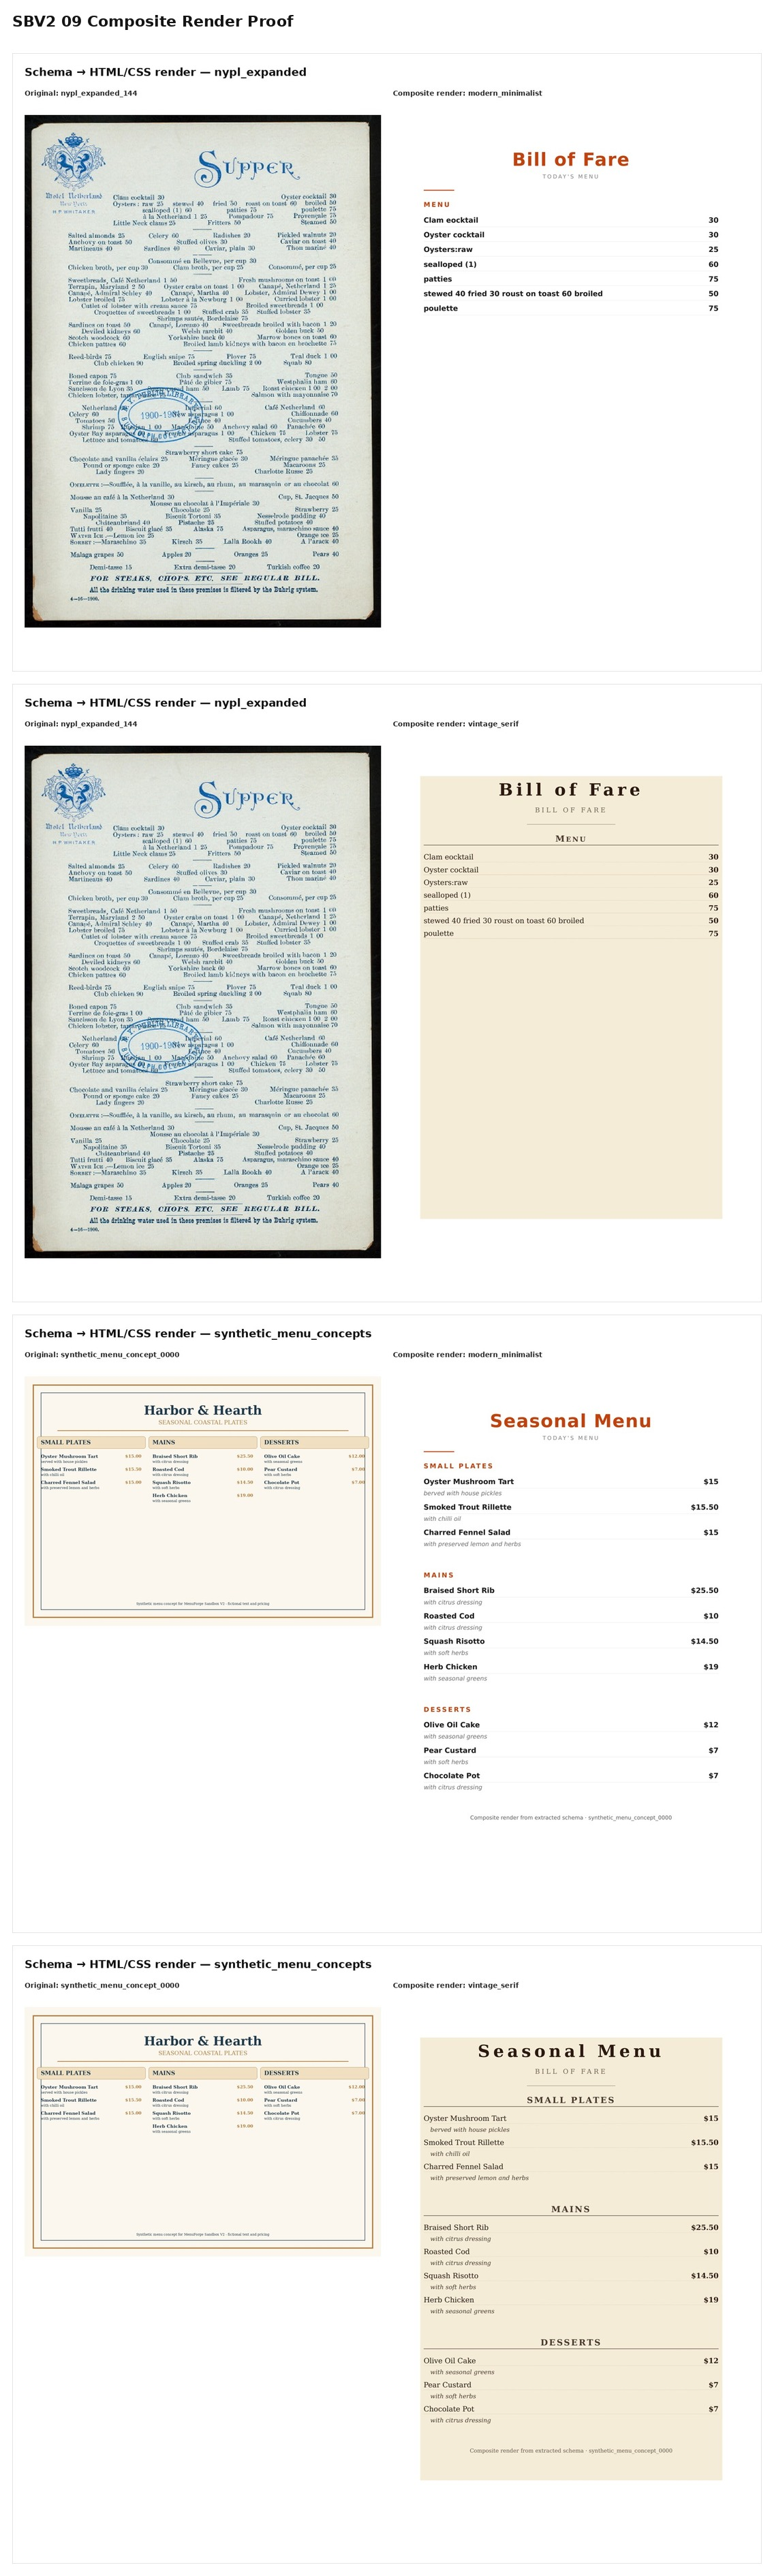

In [6]:
headline = summary.get("headline_figure")
if headline and (ROOT / headline).exists():
    display(Markdown("### Headline figure — Schema → HTML/CSS render, side-by-side with the source image"))
    display(Image(filename=str(ROOT / headline)))
else:
    display(Markdown("_Headline figure not produced._"))

#### nypl_expanded | nypl_expanded_144 | modern_minimalist

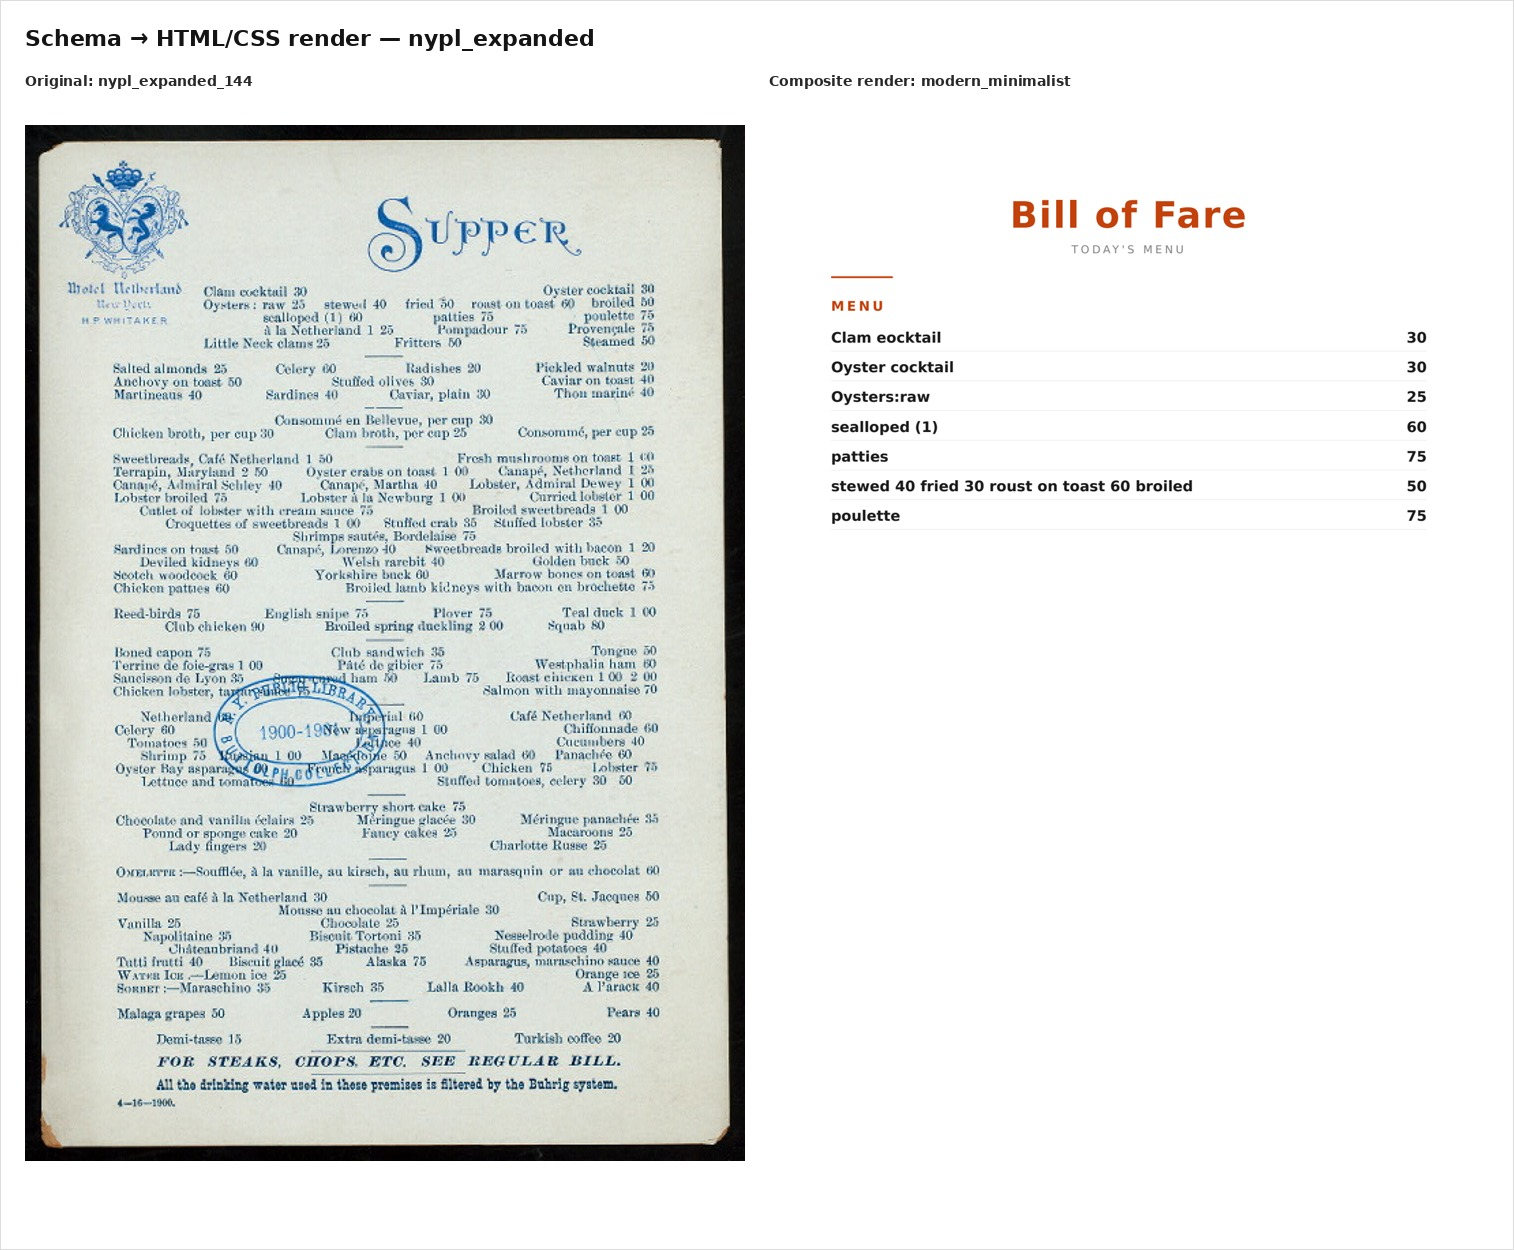

#### nypl_expanded | nypl_expanded_144 | vintage_serif

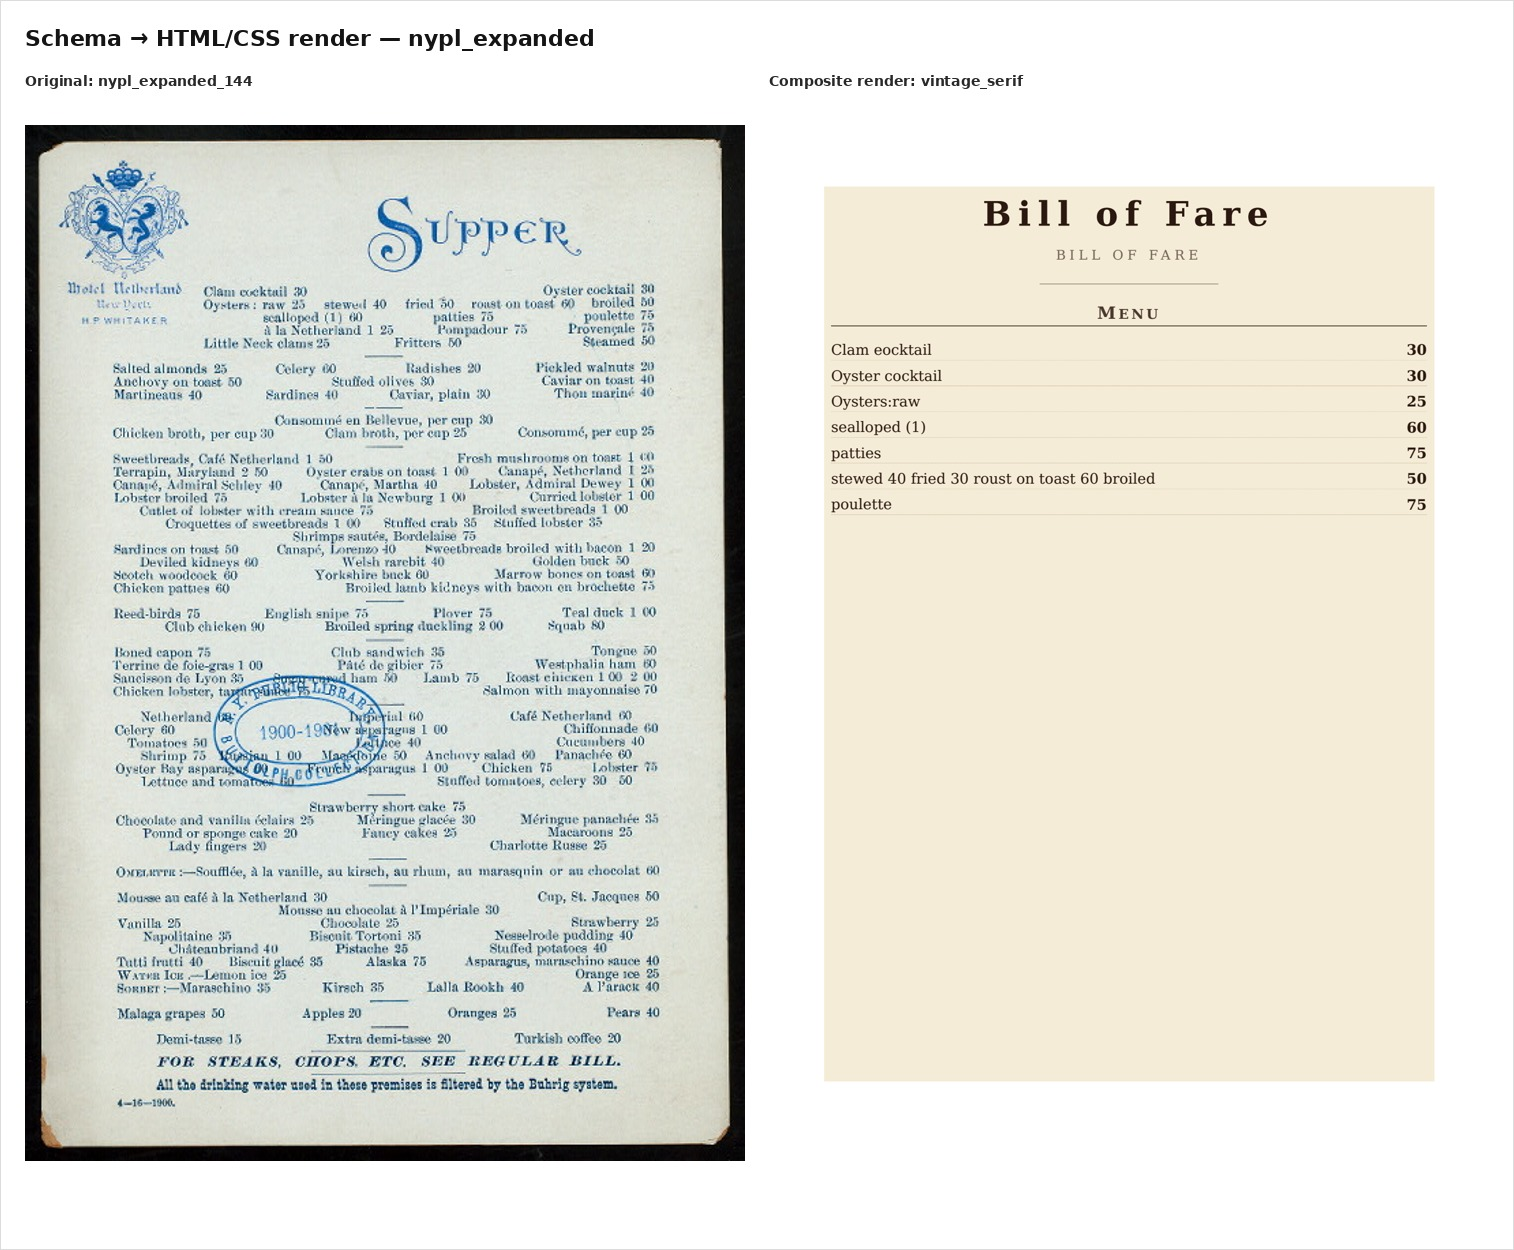

#### synthetic_menu_concepts | synthetic_menu_concept_0000 | modern_minimalist

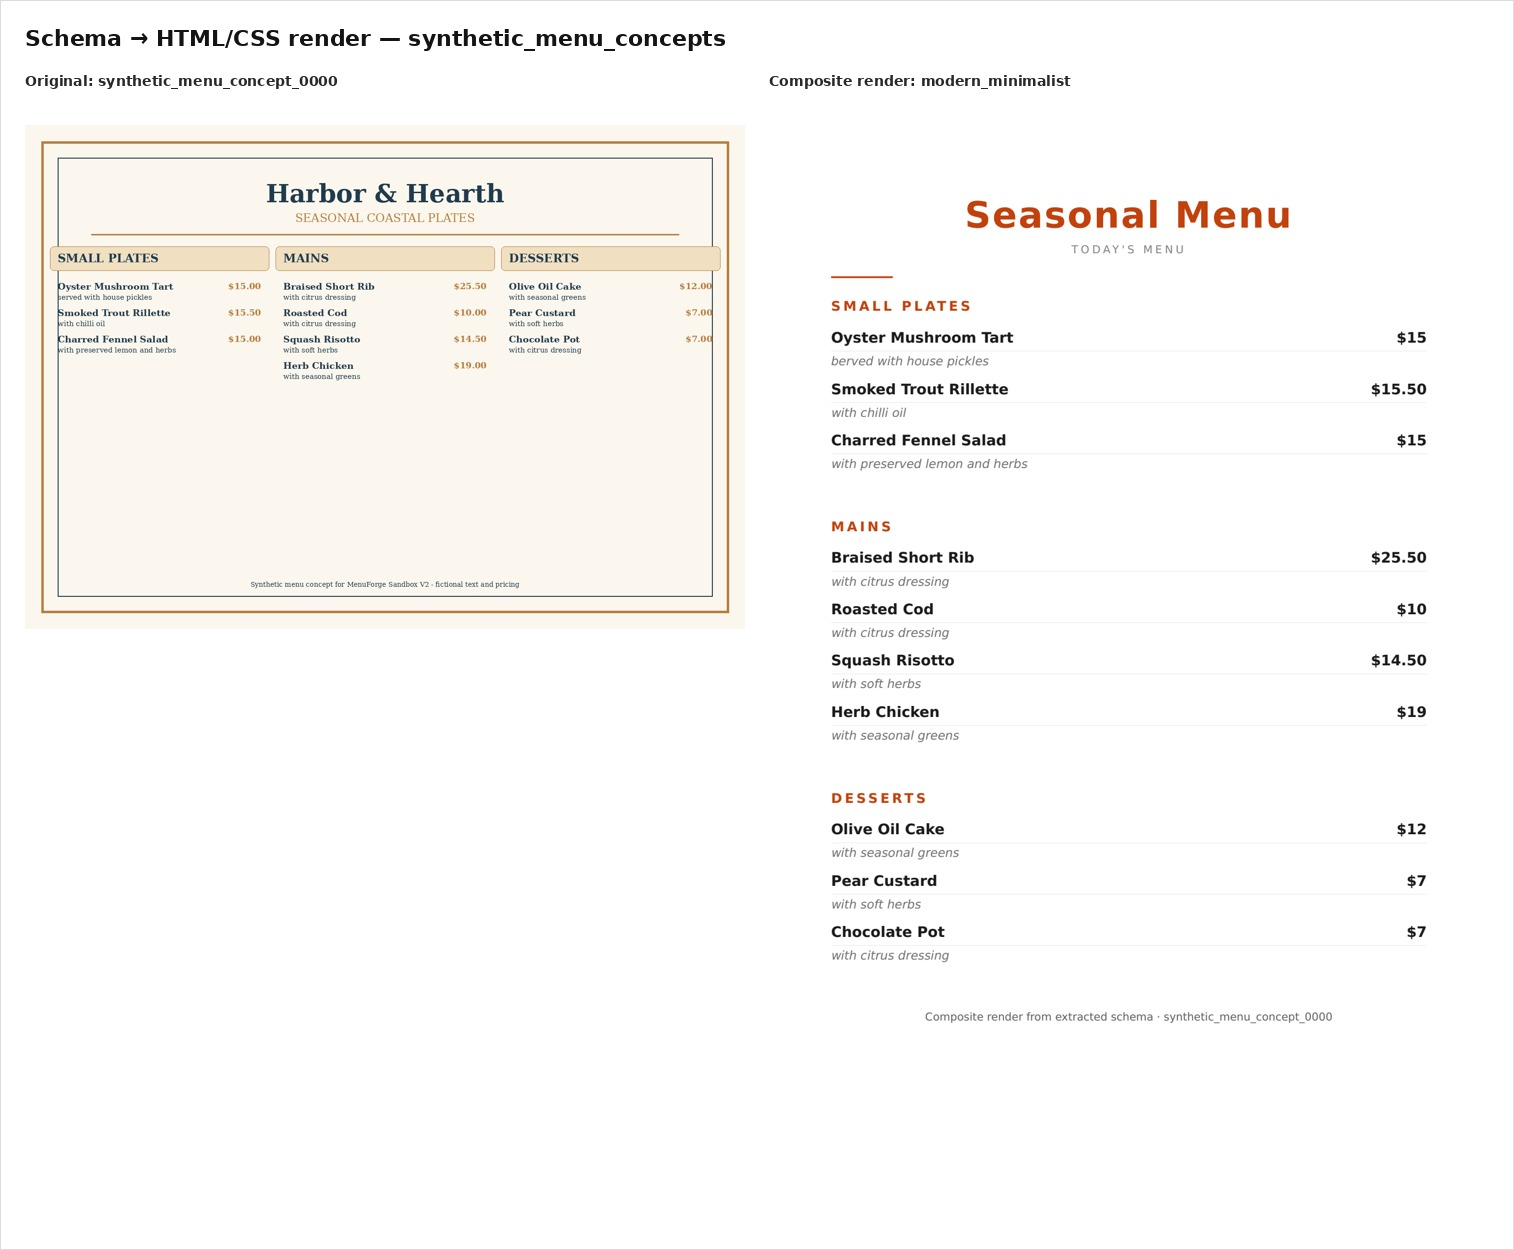

#### synthetic_menu_concepts | synthetic_menu_concept_0000 | vintage_serif

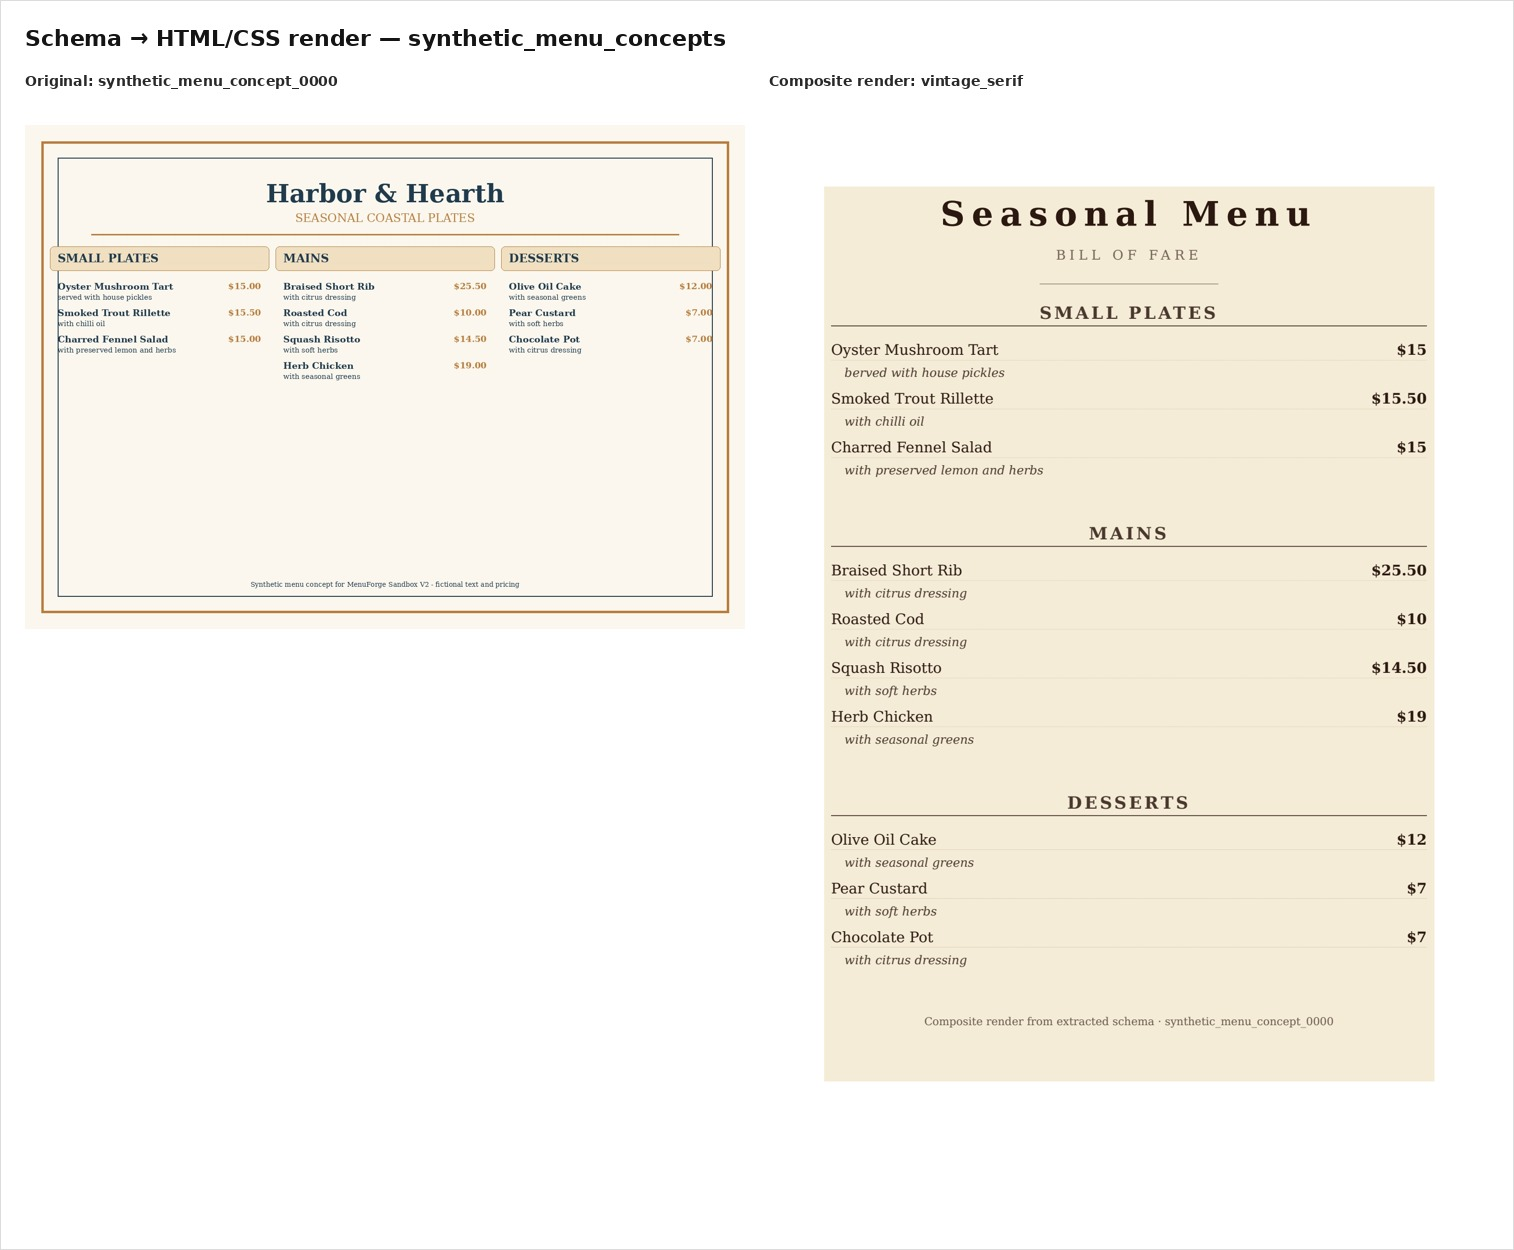

In [7]:
side_panels = audit[audit["side_by_side_path"].astype(str).str.strip() != ""]
for _, row in side_panels.iterrows():
    display(Markdown(f"#### {row['source_id']} | {row['document_id']} | {row['style']}"))
    p = ROOT / row["side_by_side_path"]
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown("_panel missing_"))

## Interpretation

What this notebook proves and does **not** prove:

- **Proves:** the OCR-derived schema is sufficient to reconstruct an exact, branded menu artefact via a deterministic render path. Item names and prices that the schema captured will reach the rendered PNG with no hallucination, because the render is template substitution rather than generation. The post-render OCR check quantifies how reliably the rendered text is *re-readable* at the chosen DPI and font stack — a crude but useful trust gate.
- **Does not prove:** that arbitrary documents can be cleanly rendered. The synthetic menu has clean ground-truth schema rows and renders cleanly; the antique NYPL menu has noisier schema rows (split item names, missing currency, mixed sections) and the render visibly inherits that noise. That is the correct evidence to publish, not a defect to hide.

Read alongside Notebook 8: the readiness gate decided which documents were eligible for this stage. The two documents that reached this notebook are exactly the two that the gate marked `ready_for_generation`. The render-and-OCR-verify loop then turns the eligibility decision into a measurable contract.

## Handoff to the horizon-scan rewrite

The headline figure `outputs/figures/sandbox_v2/sbv2_09_composite_render_proof.jpg` is the single most defensible *generation artefact* the sandbox produces. Use it as the production-path proof in the scan, paired with `sbv2_08_readiness_scores.png` as the gate that selects which documents reach the renderer. The audit CSV `sbv2_09_composite_render_audit.csv` provides per-row item/price coverage numbers for the methodology paragraph or appendix.